# Skill Profiles

## tl;dr
Built 375 eligible lagged player-season profiles; defense is represented only by block activity.

## Context & Methods
Seasonal standardized skills use at least 500 prior minutes. Shrunk three-point accuracy uses a fixed 100-attempt prior. Quality is prior Game Score/36.

### Key Assumptions
Regular-season PBP Stats aggregates; lagged profiles; observational comparisons. See [methodology](../docs/methodology_notes.md).

## Data
Run the cached pipeline and offline analysis before this notebook. No network requests are made here.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'data_pipeline.py').exists())
DATA = ROOT / 'data' / 'processed'
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
pd.set_option('display.max_columns', 12)


## Results

### Feature timing and normalization

In [2]:
profiles=pd.read_csv(DATA/'player_profiles.csv')
from src.features import SKILLS
assert ((profiles.season.str[:4].astype(int)-profiles.feature_season.str[:4].astype(int))==1).all()
display(profiles.groupby('season')[SKILLS+['quality']].mean().round(8))

,spacing,playmaking,creation,rebounding,interior,quality
season,,,,,,
2022-23,-0.0,-0.0,0.0,-0.0,-0.0,-0.0


### Recognizable player profiles

In [3]:
names=['Stephen Curry','Nikola Jokić','Rudy Gobert','Draymond Green','Luka Dončić']
display(profiles[(profiles.name.isin(names)) & (profiles.season==profiles.season.max())][['name','feature_season','prior_minutes','quality']+SKILLS].round(2))

,name,feature_season,prior_minutes,quality,spacing,playmaking,creation,rebounding,interior
54,Stephen Curry,2021-22,2211.22,1.96,2.22,1.46,1.89,-0.52,-0.61
73,Rudy Gobert,2021-22,2120.42,1.88,-1.37,-1.15,-0.37,3.18,2.79
207,Draymond Green,2021-22,1328.95,-0.13,-1.22,2.48,-0.87,0.56,1.03


### Correlated measurements

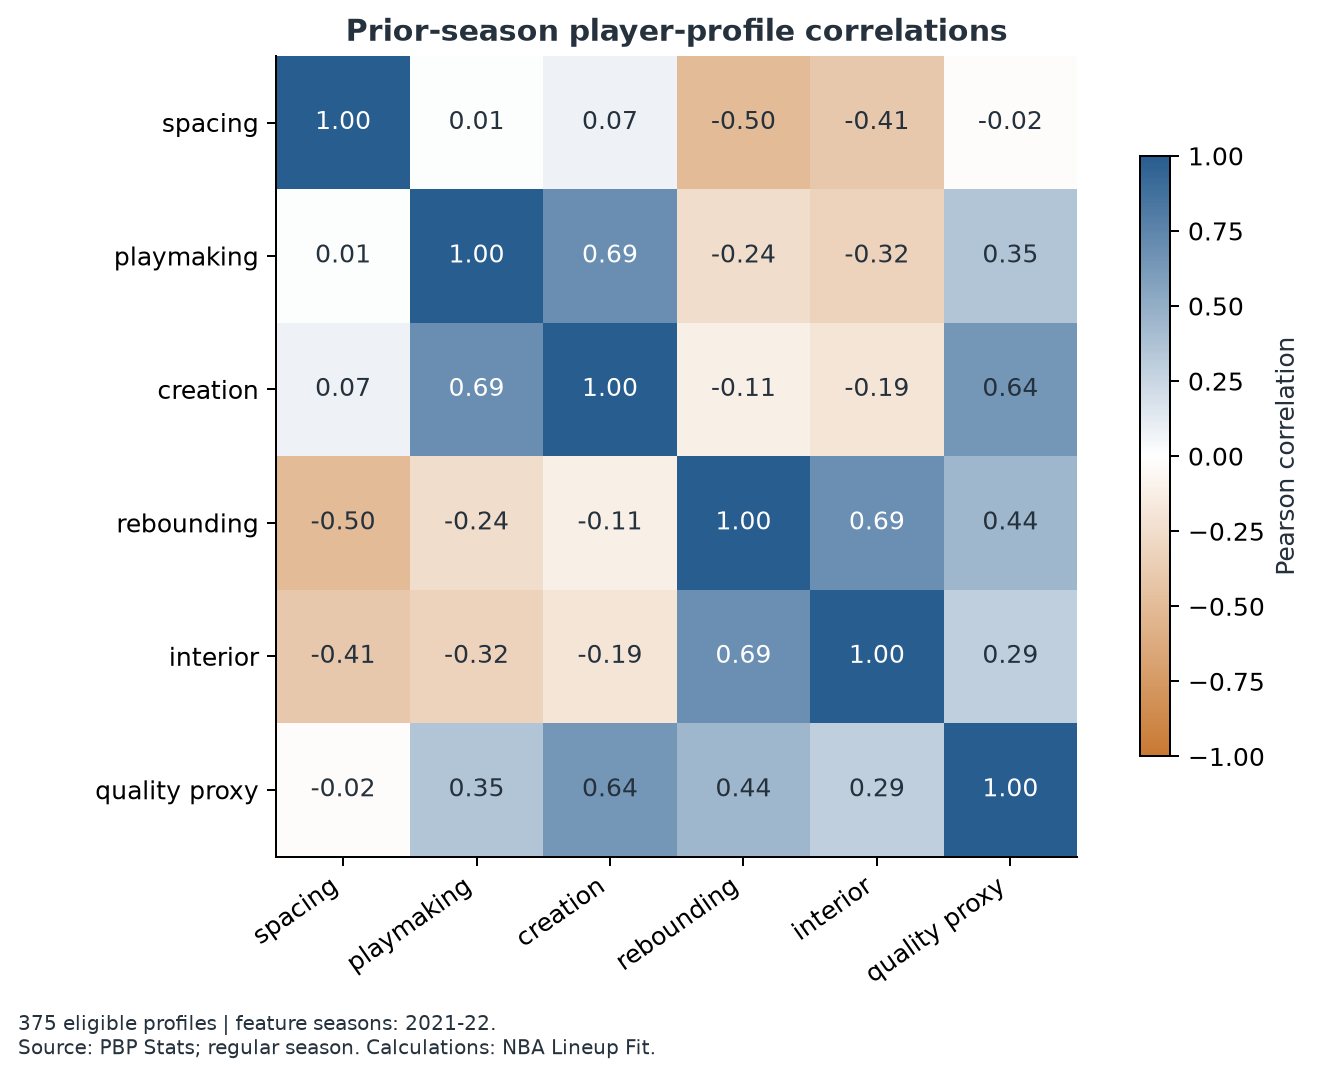

In [4]:
display(Image(filename=str(ROOT/'figures'/'skill_correlation.png')))

### Eligibility loss

In [5]:
display(pd.read_csv(DATA/'feature_coverage.csv'))

,season,core_rows,complete_rows
0,2022-23,83760,24525


## Takeaways
Box-score skills reflect roles and teammates. Blocks do not measure defense comprehensively. Missing prior history is an exclusion, not an imputed average rookie.